# Literature comparison (lidocaine)

This notebook runs the literature config and compares:
- simulated permeability (P),
- simulated lag time (Tlag),
against target values in the config.


## Setup


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()
print('repo_root:', repo_root)


repo_root: C:\Users\nwals\Documents\COMP3931_IndividualProject


## Run comparison config


In [8]:
# run calibrated literature case
cfg = load_config('configs/sim/v2_lidocaine_compare.yaml')
C_snap, t_save, D_field, k_field, patch_mask, diagnostics, metrics, stability_info = run_simulation(cfg)

# read targets
lit = cfg.extras.get('literature', {})
P_target = lit.get('P_target_cm_s')
Tlag_target_h = lit.get('Tlag_target_hours')

# read simulated outputs
P_sim = metrics.get('P')

Tlag_value = metrics.get('Tlag')
if Tlag_value is None:
    Tlag_sim_h = None
else:
    Tlag_sim_h = Tlag_value / 3600.0

print('P_sim:', P_sim)
print('P_target:', P_target)
print('Tlag_sim_h:', Tlag_sim_h)
print('Tlag_target_h:', Tlag_target_h)


simulate:   0%|          | 0/432001 [00:00<?, ?it/s]

simulate: 100%|██████████| 432001/432001 [01:16<00:00, 5649.66it/s]

P_sim: 8.053524927875683e-07
P_target: 7.38e-07
Tlag_sim_h: 1.6744111654770244
Tlag_target_h: 1.401


## Flux plot

Shows permeation flux over the full 24-hour run.


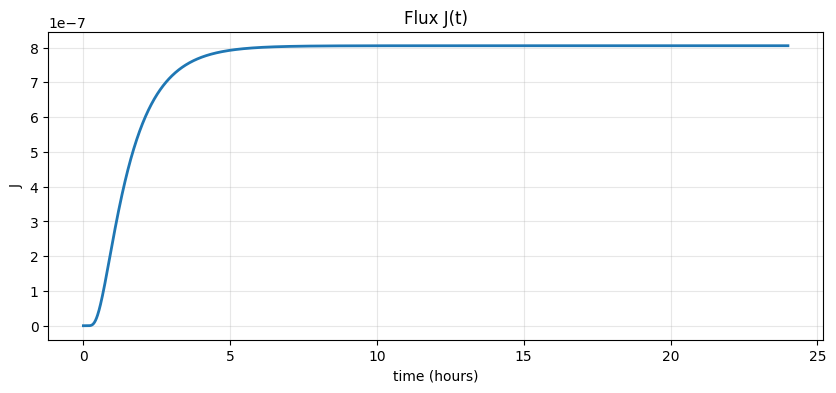

In [9]:
J = np.array(metrics['J'], dtype=float)
t_hours = np.array(metrics['t'], dtype=float) / 3600.0

plt.figure(figsize=(10, 4))
plt.plot(t_hours, J, lw=2)
plt.title('Flux J(t)')
plt.xlabel('time (hours)')
plt.ylabel('J')
plt.grid(alpha=0.3)
plt.show()


## Sim vs target + field context

First row:
- P comparison,
- Tlag comparison.

Second row:
- D field,
- final concentration map,
- final depth profile.


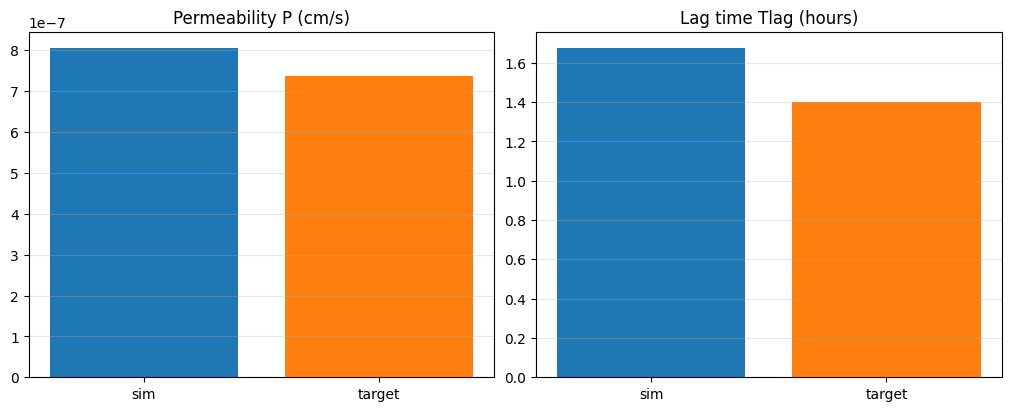

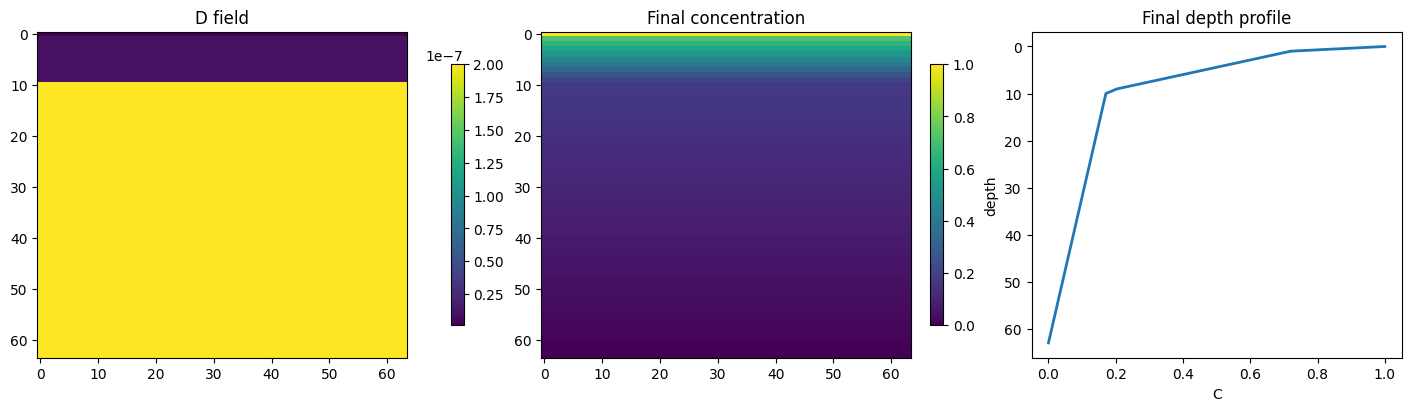

P ratio (sim/target): 1.0912635403625586
Tlag ratio (sim/target): 1.195154293702373


In [10]:
# show P and Tlag in separate charts for clear scale
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].bar(['sim', 'target'], [P_sim, P_target], color=['tab:blue', 'tab:orange'])
axes[0].set_title('Permeability P (cm/s)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['sim', 'target'], [Tlag_sim_h, Tlag_target_h], color=['tab:blue', 'tab:orange'])
axes[1].set_title('Lag time Tlag (hours)')
axes[1].grid(axis='y', alpha=0.3)

plt.show()

# show field context
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im1 = axes[0].imshow(D_field, origin='upper', aspect='auto')
axes[0].set_title('D field')
fig.colorbar(im1, ax=axes[0], shrink=0.8)

im2 = axes[1].imshow(C_snap[-1], origin='upper', aspect='auto')
axes[1].set_title('Final concentration')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

profile = C_snap[-1].mean(axis=1)
axes[2].plot(profile, np.arange(profile.size), lw=2)
axes[2].invert_yaxis()
axes[2].set_title('Final depth profile')
axes[2].set_xlabel('C')
axes[2].set_ylabel('depth')

plt.show()

# print ratios
if P_target not in [None, 0]:
    print('P ratio (sim/target):', P_sim / P_target)

if Tlag_target_h not in [None, 0] and Tlag_sim_h is not None:
    print('Tlag ratio (sim/target):', Tlag_sim_h / Tlag_target_h)
